In [1]:
"""
Creating the actual model which will be used later (best model):
 - implementing cross validation technique
 - choosing the best performing model relying on f1 metric
 - planning the strategy of reviewing messages which were placed in spam folder
"""

import warnings
import joblib
import numpy as np
import pandas as pd
import html
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")  # avoiding useless warnings

# Loading already existing preprocessed and split dataset
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze("columns")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze("columns")

In [2]:
# StratifiedKFold should keep the 87/13 class ratio in every fold the 87% is ham and 13% is spam
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [3]:
# Regularization strength (C) supports both l1 and l2 penalties.
param_grid = {"C": [0.01, 0.1, 1, 10, 100], "penalty": ["l1", "l2"]}
grid = GridSearchCV( # literally training 50 models and choosing the one with the highest f1 score
    # since f1 in this particular case is the most important metric
    LogisticRegression(solver="liblinear", max_iter=1000, random_state=42),
    param_grid, cv=cv, scoring="f1", n_jobs=-1
)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV F1 (mean over 5 folds):", round(grid.best_score_, 3))

Best params: {'C': 10, 'penalty': 'l2'}
Best CV F1 (mean over 5 folds): 0.934


In [4]:
model = grid.best_estimator_ # choosing the best model
train_predictions = model.predict(X_train) # testing the model on training data
test_predictions = model.predict(X_test) # testing the model on test data which model has never seen

print("Train accuracy:", round(accuracy_score(y_train, train_predictions), 3))
print("Test accuracy: ", round(accuracy_score(y_test, test_predictions), 3))
print("Test precision:", round(precision_score(y_test, test_predictions), 3))
print("Test recall:   ", round(recall_score(y_test, test_predictions), 3))
print("Test F1:       ", round(f1_score(y_test, test_predictions), 3))

Train accuracy: 0.988
Test accuracy:  0.988
Test precision: 0.984
Test recall:    0.924
Test F1:        0.953


In [5]:
X_train_nochi2 = pd.read_csv("../data/processed/X_train_nochi2.csv")
X_test_nochi2 = pd.read_csv("../data/processed/X_test_nochi2.csv")

In [6]:
# Regularization strength (C) supports both l1 and l2 penalties.
param_grid = {"C": [0.01, 0.1, 1, 10, 100], "penalty": ["l1", "l2"]}
grid = GridSearchCV( # literally training 50 models and choosing the one with the highest f1 score
    # since f1 in this particular case is the most important metric
    LogisticRegression(solver="liblinear", max_iter=1000, random_state=42),
    param_grid, cv=cv, scoring="f1", n_jobs=-1
)
grid.fit(X_train_nochi2, y_train)

print("Best params:", grid.best_params_)
print("Best CV F1 (mean over 5 folds):", round(grid.best_score_, 3))

Best params: {'C': 10, 'penalty': 'l2'}
Best CV F1 (mean over 5 folds): 0.936


In [7]:
model = grid.best_estimator_ # choosing the best model
train_predictions = model.predict(X_train_nochi2) # testing the model on training data
test_predictions = model.predict(X_test_nochi2) # testing the model on test data which model has never seen

print("Train accuracy:", round(accuracy_score(y_train, train_predictions), 3))
print("Test accuracy: ", round(accuracy_score(y_test, test_predictions), 3))
print("Test precision:", round(precision_score(y_test, test_predictions), 3))
print("Test recall:   ", round(recall_score(y_test, test_predictions), 3))
print("Test F1:       ", round(f1_score(y_test, test_predictions), 3))

Train accuracy: 0.998
Test accuracy:  0.99
Test precision: 0.984
Test recall:    0.939
Test F1:        0.961


In [8]:
# Save
joblib.dump(model, "../models/model.joblib")

['../models/model.joblib']

In [9]:
probs = model.predict_proba(X_test_nochi2)[:, 1]  # spam probability for each test message

In [10]:
probs

array([1.24327672e-05, 1.06477476e-03, 1.51125754e-03, ...,
       9.99999998e-01, 7.05035597e-07, 5.71308936e-04], shape=(1034,))

In [11]:
# sweep thresholds for the chart
sweep = np.arange(0.05, 1.0, 0.05) # an array from .05 up to .95
precisions, recalls, pct_flagged = [], [], [] # creating lists for further calculations
for t in sweep:
    # creating a True/False list for messages (where spam = True) for different thresholds
    flagged = probs >= t
    # filling precisions list with calculated precision score for every single threshold
    precisions.append(precision_score(y_test, flagged, zero_division=0))
    # filling recalls list with calculated recalls score for every single threshold
    recalls.append(recall_score(y_test, flagged, zero_division=0))
    # filling pct_flagged list with calculated percentage of total messages flagged as spam
    pct_flagged.append(flagged.mean() * 100)


In [12]:
print(f"Precisions: {precisions}\n\nRecalls: {recalls}\n\nTotal flagged: {pct_flagged}")

Precisions: [0.8466666666666667, 0.9, 0.9185185185185185, 0.924812030075188, 0.9389312977099237, 0.9389312977099237, 0.9534883720930233, 0.9609375, 0.968503937007874, 0.984, 0.9838709677419355, 0.9918032786885246, 0.9918032786885246, 0.9916666666666667, 0.9915254237288136, 0.9914529914529915, 1.0, 1.0, 1.0]

Recalls: [0.9694656488549618, 0.9618320610687023, 0.9465648854961832, 0.9389312977099237, 0.9389312977099237, 0.9389312977099237, 0.9389312977099237, 0.9389312977099237, 0.9389312977099237, 0.9389312977099237, 0.9312977099236641, 0.9236641221374046, 0.9236641221374046, 0.9083969465648855, 0.8931297709923665, 0.8854961832061069, 0.8778625954198473, 0.8625954198473282, 0.816793893129771]

Total flagged: [np.float64(14.506769825918761), np.float64(13.539651837524177), np.float64(13.056092843326885), np.float64(12.86266924564797), np.float64(12.669245647969053), np.float64(12.669245647969053), np.float64(12.475822050290136), np.float64(12.379110251450678), np.float64(12.282398452611218

In [13]:
print("threshold | precision | recall | Total flagged %")
for t, p, r, f in zip(sweep, precisions, recalls, pct_flagged):
    print(f"   {t:.2f}       {p:.3f}     {r:.3f}        {f:2.2f}%")

threshold | precision | recall | Total flagged %
   0.05       0.847     0.969        14.51%
   0.10       0.900     0.962        13.54%
   0.15       0.919     0.947        13.06%
   0.20       0.925     0.939        12.86%
   0.25       0.939     0.939        12.67%
   0.30       0.939     0.939        12.67%
   0.35       0.953     0.939        12.48%
   0.40       0.961     0.939        12.38%
   0.45       0.969     0.939        12.28%
   0.50       0.984     0.939        12.09%
   0.55       0.984     0.931        11.99%
   0.60       0.992     0.924        11.80%
   0.65       0.992     0.924        11.80%
   0.70       0.992     0.908        11.61%
   0.75       0.992     0.893        11.41%
   0.80       0.991     0.885        11.32%
   0.85       1.000     0.878        11.12%
   0.90       1.000     0.863        10.93%
   0.95       1.000     0.817        10.35%


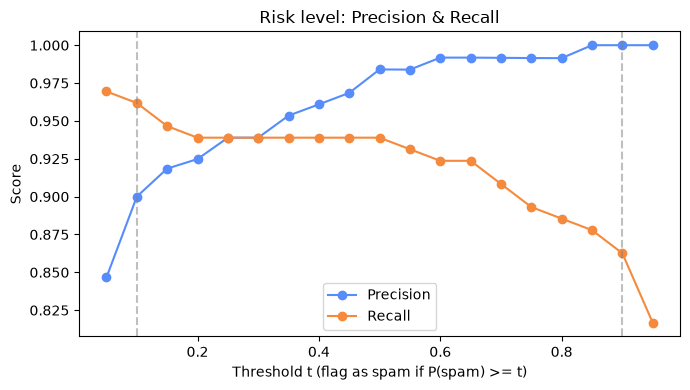

In [14]:
# Plot for the report: precision & recall as the threshold moves
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sweep, precisions, marker="o", label="Precision")
ax.plot(sweep, recalls, marker="o", label="Recall")
ax.set_xlabel("Threshold t (flag as spam if P(spam) >= t)")
ax.set_ylabel("Score")
ax.set_title("Risk level: Precision & Recall")
ax.axvline(0.10, color="gray", linestyle="--", alpha=0.5)
ax.axvline(0.90, color="gray", linestyle="--", alpha=0.5)
ax.legend()
plt.tight_layout()
plt.savefig("../figures/risk_level_nochi2.png", dpi=150)
plt.show()
plt.close()

In [15]:
# four concrete settings for the service team
print("Example settings:\n")
levels = [(.1, "Low risk (restrictive)"), (0.40, "Balanced towards safety (somewhat restrictive)"), (0.75, "Medium risk (lenient)"), (0.95, "High risk (Not restrictive)")]
for t, label in levels:
    flagged = probs >= t # 1 if confidence of the model is higher than the threshold, otherwise 0
    p = precision_score(y_test, flagged, zero_division=0)
    r = recall_score(y_test, flagged, zero_division=0)
    print(f"""{label} t={t:.2f} ->{flagged.mean()*100:.1f}% of messages sent to review
    Catches {r*100:.1f}% of real spam, {p*100:.1f}% of what's flagged really is spam\n""")

Example settings:

Low risk (restrictive) t=0.10 ->13.5% of messages sent to review
    Catches 96.2% of real spam, 90.0% of what's flagged really is spam

Balanced towards safety (somewhat restrictive) t=0.40 ->12.4% of messages sent to review
    Catches 93.9% of real spam, 96.1% of what's flagged really is spam

Medium risk (lenient) t=0.75 ->11.4% of messages sent to review
    Catches 89.3% of real spam, 99.2% of what's flagged really is spam

High risk (Not restrictive) t=0.95 ->10.3% of messages sent to review
    Catches 81.7% of real spam, 100.0% of what's flagged really is spam



In [16]:
# Loading the original raw dataset as current X_test has only numerical features for machines and not for users
df_raw = pd.read_csv("../data/raw/SMSSpamCollection.csv", sep="\t", header=None, names=["label", "message"])
df_raw["message"] = df_raw["message"].apply(html.unescape)
df_raw = df_raw.drop_duplicates(subset=["message", "label"]).reset_index(drop=True)
y_full = df_raw["label"].map({"ham": 0, "spam": 1})
_, X_test_raw, _, _ = train_test_split(df_raw, y_full, train_size=0.80, random_state=42, stratify=y_full)
messages = X_test_raw["message"].reset_index(drop=True)

In [17]:
threshold = levels[0][0] # lowest risk level
spam_threshold = levels[3][0] # spam threshold

# All mails are place initially in folder variable
folder = pd.DataFrame({"message": messages, "p_spam": probs, "true_label": y_test.values})
# In case if the confidence of a model that mail is spam is less than 10% then the mail gets into Inbox
inbox_df = folder[folder["p_spam"] < threshold].reset_index(drop=True)
# In case if the confidence of a model that mail is spam is less than 90%
# but higher than 10% then the mail gets into Review folder
review_folder_df = folder[(folder["p_spam"] >= threshold) & (folder["p_spam"] <= spam_threshold)].copy()
# In case if the confidence of a model that mail is spam is more than 95% then the mail gets into Spam folder
spam_folder_df = folder[folder["p_spam"] > spam_threshold].copy()

print(f"Inbox (shown immediately): {len(inbox_df)}")
print(f"Review folder (further analysis): {len(review_folder_df)}")
print(f"Spam folder (putted into spam folder immediately): {len(spam_folder_df)}")

Inbox (shown immediately): 894
Review folder (further analysis): 33
Spam folder (putted into spam folder immediately): 107


In [18]:
# Strategy for further analysis, so as not to lose customers
"""Not every flagged message deserves the same wait. A message that's only slightly over
the line is much more likely a real customer than one the model is almost certain is
spam, so the queue is ordered to review those first, with a matching SLA per tier."""

def priority_tier(p):
    if p < levels[1][0]: # Confidence of the model that mail is spam is less than 40%
        return "High (likely a real customer)"
    elif p < levels[2][0]: # Confidence of the model that mail is spam is less than 75%
        return "Medium (genuinely uncertain)"
    # Confidence of the model that mail is spam is more than 75%
    return "Low (likely spam)"

# setting a review time for every single mail according to risk level
sla_hours = {"High (likely a real customer)": 1, "Medium (genuinely uncertain)": 7, "Low (likely spam)": 24}
received_at = pd.Timestamp.now(tz="Europe/Belgrade") # choosing the most appropriate timezone. BG for me :-)

review_folder_df["priority"] = review_folder_df["p_spam"].apply(priority_tier)
review_folder_df["received_at"] = received_at
review_folder_df["review_by"] = review_folder_df["priority"].map(
    lambda x: (received_at + pd.Timedelta(hours=sla_hours[x])).strftime("%d/%m/%Y %H:%M"))

# the messages in review folder are being sorted via review by time, but in next order:
# messages with High (likely a real customer) status are being added 1 hour to their delivery time
# messages with Medium (genuinely uncertain) status are being added 7 hour to their delivery time
# messages with Low (likely spam) status are being added 24 hour to their delivery time
review_folder_df = review_folder_df.sort_values("review_by", ascending=True).reset_index(drop=True)
review_folder_df["queue_position"] = review_folder_df.index + 1

print(review_folder_df["priority"].value_counts())

priority
High (likely a real customer)    12
Low (likely spam)                11
Medium (genuinely uncertain)     10
Name: count, dtype: int64


In [19]:
inbox_df.head(5)

,message,p_spam,true_label
0,"Good morning, my Love ... I go to sleep now an...",0.000012,0
1,"And how you will do that, princess? :)",0.001065,0
2,"Cool, I'll text you when I'm on the way",0.001511,0
3,Your right! I'll make the appointment right now.,0.000467,0
4,Aiya we discuss later lar... Pick ü up at 4 is...,0.000295,0


In [20]:
spam_folder_df.head(5)

,message,p_spam,true_label
55,I am hot n horny and willing I live local to y...,0.999998,1
71,Your unique user ID is 1172. For removal send ...,0.999631,1
95,Want explicit SEX in 30 secs? Ring 02073162414...,0.995553,1
102,Someone has contacted our dating service and e...,0.999996,1
108,Todays Vodafone numbers ending with 4882 are s...,0.999819,1


In [21]:
review_folder_df["decision"] = ""  # user fills in: "ham" or "spam"
review_folder_df.to_csv("../data/review_folder.csv", index=False)
print(f"{len(review_folder_df)} messages awaiting review")

33 messages awaiting review


In [22]:
review_folder_df.head(5)

,message,p_spam,true_label,priority,received_at,review_by,queue_position,decision
0,You will recieve your tone within the next 24h...,0.125134,1,High (likely a real customer),2026-09-08 21:47:40.342549+02:00,08/09/2026 22:47,1,
1,How to Make a girl Happy? It's not at all diff...,0.311212,0,High (likely a real customer),2026-09-08 21:47:40.342549+02:00,08/09/2026 22:47,2,
2,I am waiting machan. Call me once you free.,0.113505,0,High (likely a real customer),2026-09-08 21:47:40.342549+02:00,08/09/2026 22:47,3,
3,"You are everywhere dirt, on the floor, the win...",0.137168,0,High (likely a real customer),2026-09-08 21:47:40.342549+02:00,08/09/2026 22:47,4,
4,K k:) sms chat with me.,0.166333,0,High (likely a real customer),2026-09-08 21:47:40.342549+02:00,08/09/2026 22:47,5,


In [23]:
# Top of the queue: reviewed first
review_folder_df[["queue_position", "p_spam", "priority", "review_by", "message"]].head(5)

,queue_position,p_spam,priority,review_by,message
0,1,0.125134,High (likely a real customer),08/09/2026 22:47,You will recieve your tone within the next 24h...
1,2,0.311212,High (likely a real customer),08/09/2026 22:47,How to Make a girl Happy? It's not at all diff...
2,3,0.113505,High (likely a real customer),08/09/2026 22:47,I am waiting machan. Call me once you free.
3,4,0.137168,High (likely a real customer),08/09/2026 22:47,"You are everywhere dirt, on the floor, the win..."
4,5,0.166333,High (likely a real customer),08/09/2026 22:47,K k:) sms chat with me.
